# Exploratory Data Analysis of the 2023 ATP Tennis Season

## Objective

To explore match outcomes, surface distribution, ranking impact and player performance trends in the 2023 ATP season.

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("atp_matches_2023.csv")


## Data Overview
df.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2023-9900,United Cup,Hard,18,A,20230102,300,126203,3.0,NaN,...,62.0,47.0,15.0,12.0,9.0,9.0,9.0,3355.0,16.0,2375.0
1,2023-9900,United Cup,Hard,18,A,20230102,299,126207,NaN,NaN,...,12.0,8.0,3.0,4.0,1.0,3.0,19.0,2000.0,23.0,1865.0
2,2023-9900,United Cup,Hard,18,A,20230102,296,126203,3.0,NaN,...,62.0,51.0,7.0,12.0,2.0,2.0,9.0,3355.0,10.0,2905.0
3,2023-9900,United Cup,Hard,18,A,20230102,295,126207,NaN,NaN,...,41.0,26.0,12.0,9.0,6.0,9.0,19.0,2000.0,245.0,220.0
4,2023-9900,United Cup,Hard,18,A,20230102,292,126774,1.0,NaN,...,58.0,48.0,18.0,16.0,1.0,2.0,4.0,5550.0,16.0,2375.0


In [3]:
df.shape



(2986, 49)

In [4]:
df.columns


Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points'],
      dtype='str')

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2986 entries, 0 to 2985
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          2986 non-null   str    
 1   tourney_name        2986 non-null   str    
 2   surface             2933 non-null   str    
 3   draw_size           2986 non-null   int64  
 4   tourney_level       2986 non-null   str    
 5   tourney_date        2986 non-null   int64  
 6   match_num           2986 non-null   int64  
 7   winner_id           2986 non-null   int64  
 8   winner_seed         1250 non-null   float64
 9   winner_entry        473 non-null    str    
 10  winner_name         2986 non-null   str    
 11  winner_hand         2986 non-null   str    
 12  winner_ht           2969 non-null   float64
 13  winner_ioc          2986 non-null   str    
 14  winner_age          2986 non-null   float64
 15  loser_id            2986 non-null   int64  
 16  loser_seed       

In [6]:
df.describe()


,draw_size,tourney_date,match_num,winner_id,winner_seed,winner_ht,winner_age,loser_id,loser_seed,loser_ht,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
count,2986.000000,2.986000e+03,2986.00000,2986.000000,1250.000000,2969.000000,2986.000000,2986.000000,769.000000,2954.000000,...,2815.000000,2815.000000,2815.000000,2815.000000,2815.000000,2815.000000,2964.000000,2964.000000,2955.000000,2955.000000
mean,64.901541,2.023057e+07,235.88781,145036.088078,7.821600,187.552375,26.587609,144006.518084,9.690507,186.631686,...,50.658259,34.179751,14.561989,12.495915,4.708703,8.327176,74.961876,1712.911269,114.104907,1104.327242
std,46.314680,3.058956e+02,82.33363,42766.699797,7.204728,6.912431,4.351220,42450.867025,8.099507,6.621530,...,18.851845,14.214984,6.758157,4.165111,3.265831,4.136515,116.119939,1823.309976,181.817105,1180.899962
min,2.000000,2.023010e+07,1.00000,100644.000000,1.000000,71.000000,17.900000,100644.000000,1.000000,170.000000,...,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,32.000000,2.023031e+07,208.00000,106331.000000,3.000000,183.000000,23.900000,106233.000000,4.000000,183.000000,...,37.000000,24.000000,10.000000,9.000000,2.000000,5.000000,17.000000,662.000000,36.000000,532.500000
50%,32.000000,2.023053e+07,275.00000,126205.000000,6.000000,188.000000,26.100000,126205.000000,7.000000,185.000000,...,47.000000,32.000000,14.000000,12.000000,4.000000,8.000000,48.000000,931.000000,67.000000,782.000000
75%,128.000000,2.023082e+07,289.00000,200325.000000,10.000000,193.000000,28.400000,200318.000000,13.000000,191.000000,...,62.000000,43.000000,18.000000,15.000000,6.000000,11.000000,87.000000,2063.750000,111.000000,1122.500000
max,128.000000,2.023113e+07,300.00000,212051.000000,32.000000,208.000000,43.600000,212044.000000,32.000000,208.000000,...,143.000000,101.000000,47.000000,31.000000,20.000000,28.000000,1594.000000,11795.000000,2050.000000,11245.000000


In [7]:
df.isnull().sum()


tourney_id               0
tourney_name             0
surface                 53
draw_size                0
tourney_level            0
tourney_date             0
match_num                0
winner_id                0
winner_seed           1736
winner_entry          2513
winner_name              0
winner_hand              0
winner_ht               17
winner_ioc               0
winner_age               0
loser_id                 0
loser_seed            2217
loser_entry           2291
loser_name               0
loser_hand               0
loser_ht                32
loser_ioc                0
loser_age                2
score                    0
best_of                  0
round                    0
minutes                232
w_ace                  171
w_df                   171
w_svpt                 171
w_1stIn                171
w_1stWon               171
w_2ndWon               171
w_SvGms                171
w_bpSaved              171
w_bpFaced              171
l_ace                  171
l

In [8]:
df[["winner_rank", "loser_rank"]].isnull().sum()


winner_rank    22
loser_rank     31
dtype: int64

In [9]:
df = df.dropna(subset=["winner_rank", "loser_rank"])


In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2986 entries, 0 to 2985
Data columns (total 49 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tourney_id          2986 non-null   str    
 1   tourney_name        2986 non-null   str    
 2   surface             2933 non-null   str    
 3   draw_size           2986 non-null   int64  
 4   tourney_level       2986 non-null   str    
 5   tourney_date        2986 non-null   int64  
 6   match_num           2986 non-null   int64  
 7   winner_id           2986 non-null   int64  
 8   winner_seed         1250 non-null   float64
 9   winner_entry        473 non-null    str    
 10  winner_name         2986 non-null   str    
 11  winner_hand         2986 non-null   str    
 12  winner_ht           2969 non-null   float64
 13  winner_ioc          2986 non-null   str    
 14  winner_age          2986 non-null   float64
 15  loser_id            2986 non-null   int64  
 16  loser_seed       

,draw_size,tourney_date,match_num,winner_id,winner_seed,winner_ht,winner_age,loser_id,loser_seed,loser_ht,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
count,2986.000000,2.986000e+03,2986.00000,2986.000000,1250.000000,2969.000000,2986.000000,2986.000000,769.000000,2954.000000,...,2815.000000,2815.000000,2815.000000,2815.000000,2815.000000,2815.000000,2964.000000,2964.000000,2955.000000,2955.000000
mean,64.901541,2.023057e+07,235.88781,145036.088078,7.821600,187.552375,26.587609,144006.518084,9.690507,186.631686,...,50.658259,34.179751,14.561989,12.495915,4.708703,8.327176,74.961876,1712.911269,114.104907,1104.327242
std,46.314680,3.058956e+02,82.33363,42766.699797,7.204728,6.912431,4.351220,42450.867025,8.099507,6.621530,...,18.851845,14.214984,6.758157,4.165111,3.265831,4.136515,116.119939,1823.309976,181.817105,1180.899962
min,2.000000,2.023010e+07,1.00000,100644.000000,1.000000,71.000000,17.900000,100644.000000,1.000000,170.000000,...,3.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,32.000000,2.023031e+07,208.00000,106331.000000,3.000000,183.000000,23.900000,106233.000000,4.000000,183.000000,...,37.000000,24.000000,10.000000,9.000000,2.000000,5.000000,17.000000,662.000000,36.000000,532.500000
50%,32.000000,2.023053e+07,275.00000,126205.000000,6.000000,188.000000,26.100000,126205.000000,7.000000,185.000000,...,47.000000,32.000000,14.000000,12.000000,4.000000,8.000000,48.000000,931.000000,67.000000,782.000000
75%,128.000000,2.023082e+07,289.00000,200325.000000,10.000000,193.000000,28.400000,200318.000000,13.000000,191.000000,...,62.000000,43.000000,18.000000,15.000000,6.000000,11.000000,87.000000,2063.750000,111.000000,1122.500000
max,128.000000,2.023113e+07,300.00000,212051.000000,32.000000,208.000000,43.600000,212044.000000,32.000000,208.000000,...,143.000000,101.000000,47.000000,31.000000,20.000000,28.000000,1594.000000,11795.000000,2050.000000,11245.000000


In [11]:
df["tourney_name"].nunique()


140

In [12]:
df["surface"].value_counts()


surface
Hard     1692
Clay      894
Grass     318
Name: count, dtype: int64

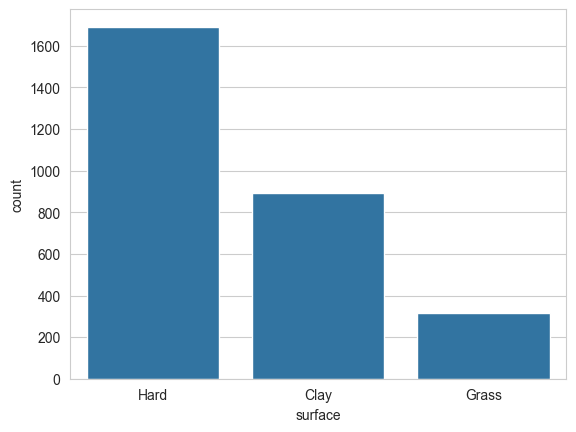

In [13]:
sns.countplot(x="surface", data=df)
plt.show()


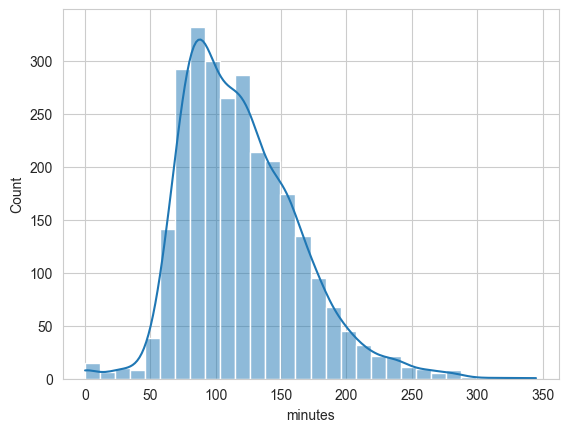

In [14]:
sns.histplot(df["minutes"], bins=30, kde=True)
plt.show()


In [15]:
df["rank_diff"] = df["loser_rank"] - df["winner_rank"]


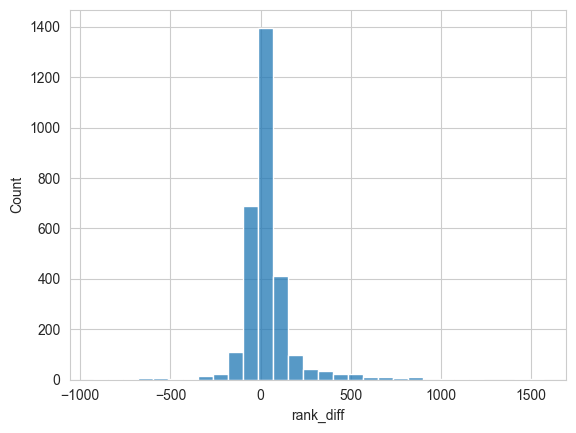

In [16]:
sns.histplot(df["rank_diff"], bins=30)
plt.show()


In [17]:
(df["rank_diff"] > 0).mean()


np.float64(0.6329931972789116)

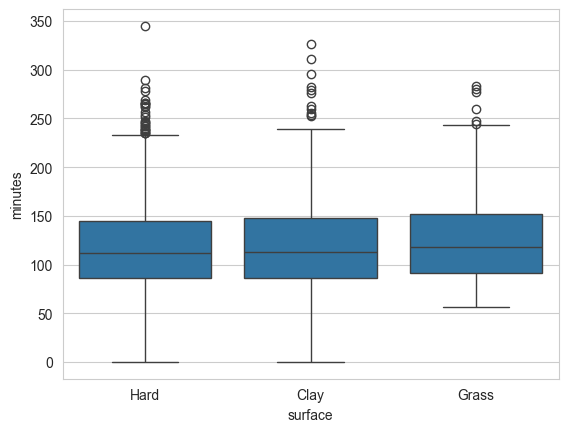

In [18]:
sns.boxplot(x="surface", y="minutes", data=df)
plt.show()


In [19]:
top_players = df["winner_name"].value_counts().head(10)
top_players


winner_name
Daniil Medvedev       66
Jannik Sinner         66
Carlos Alcaraz        65
Novak Djokovic        56
Andrey Rublev         56
Alexander Zverev      55
Taylor Fritz          53
Stefanos Tsitsipas    50
Alex De Minaur        48
Holger Rune           46
Name: count, dtype: int64

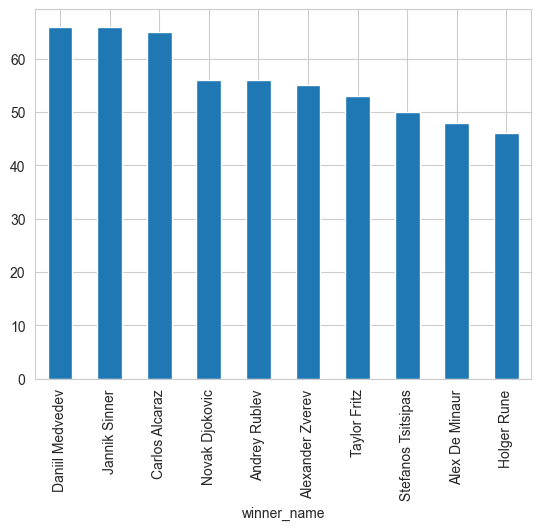

In [20]:
top_players.plot(kind="bar")
plt.show()


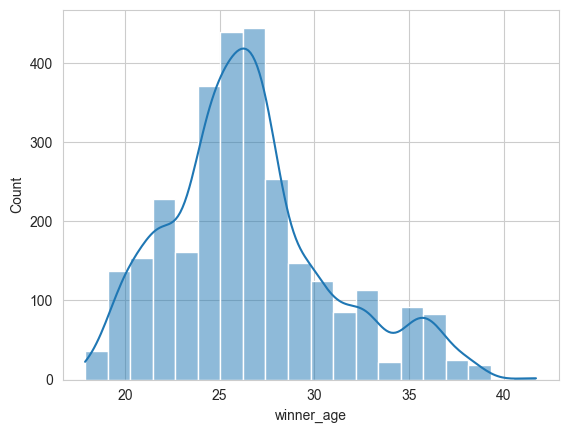

In [21]:
sns.histplot(df["winner_age"], bins=20, kde=True)
plt.show()


In [22]:
df.isnull().sum()


tourney_id               0
tourney_name             0
surface                 36
draw_size                0
tourney_level            0
tourney_date             0
match_num                0
winner_id                0
winner_seed           1695
winner_entry          2470
winner_name              0
winner_hand              0
winner_ht                6
winner_ioc               0
winner_age               0
loser_id                 0
loser_seed            2172
loser_entry           2251
loser_name               0
loser_hand               0
loser_ht                 7
loser_ioc                0
loser_age                0
score                    0
best_of                  0
round                    0
minutes                199
w_ace                  138
w_df                   138
w_svpt                 138
w_1stIn                138
w_1stWon               138
w_2ndWon               138
w_SvGms                138
w_bpSaved              138
w_bpFaced              138
l_ace                  138
l

In [23]:
df["tourney_date"] = pd.to_datetime(df["tourney_date"], format="%Y%m%d")


In [24]:
df.duplicated().sum()


np.int64(0)

In [25]:
df.drop_duplicates(inplace=True)


<Axes: xlabel='minutes'>

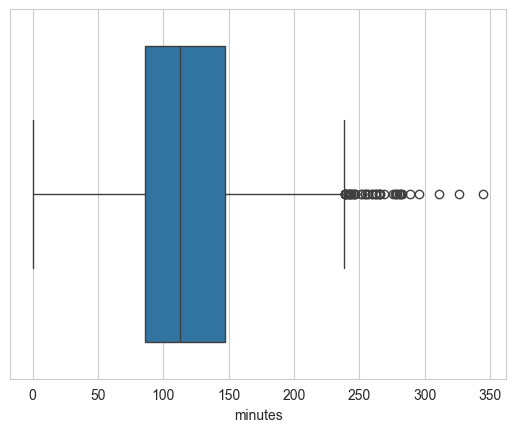

In [26]:
sns.boxplot(x=df["minutes"])


In [27]:
df = df[df["minutes"] < 400]


In [28]:
df.shape


(2741, 50)

In [29]:
df.info()


<class 'pandas.DataFrame'>
Index: 2741 entries, 0 to 2765
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tourney_id          2741 non-null   str           
 1   tourney_name        2741 non-null   str           
 2   surface             2741 non-null   str           
 3   draw_size           2741 non-null   int64         
 4   tourney_level       2741 non-null   str           
 5   tourney_date        2741 non-null   datetime64[us]
 6   match_num           2741 non-null   int64         
 7   winner_id           2741 non-null   int64         
 8   winner_seed         1238 non-null   float64       
 9   winner_entry        468 non-null    str           
 10  winner_name         2741 non-null   str           
 11  winner_hand         2741 non-null   str           
 12  winner_ht           2741 non-null   float64       
 13  winner_ioc          2741 non-null   str           
 14  winner_a

In [30]:
df["tourney_date"] = pd.to_datetime(df["tourney_date"], format="%Y%m%d")


In [31]:
df["tourney_date"].head()


0   2023-01-02
1   2023-01-02
2   2023-01-02
3   2023-01-02
4   2023-01-02
Name: tourney_date, dtype: datetime64[us]

In [32]:
df.isnull().sum().sort_values(ascending=False)


winner_entry          2273
loser_entry           2052
loser_seed            1979
winner_seed           1503
l_1stIn                 14
l_df                    14
w_svpt                  14
w_1stIn                 14
w_1stWon                14
w_2ndWon                14
w_SvGms                 14
w_bpSaved               14
w_bpFaced               14
l_ace                   14
w_df                    14
l_svpt                  14
w_ace                   14
l_1stWon                14
l_2ndWon                14
l_SvGms                 14
l_bpSaved               14
l_bpFaced               14
winner_rank              0
winner_rank_points       0
loser_rank               0
loser_rank_points        0
tourney_id               0
round                    0
minutes                  0
tourney_name             0
surface                  0
draw_size                0
tourney_level            0
tourney_date             0
match_num                0
winner_id                0
winner_name              0
w

In [33]:
df = df.dropna(subset=["winner_rank", "loser_rank"])


In [34]:
df.duplicated().sum()


np.int64(0)

In [35]:
df.drop_duplicates(inplace=True)


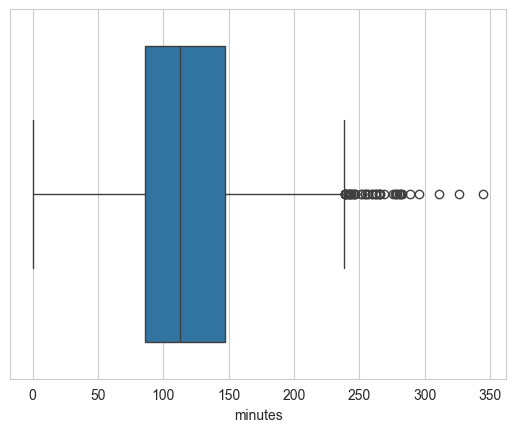

In [36]:
sns.boxplot(x=df["minutes"])
plt.show()


In [37]:
df = df[df["minutes"] < 400]


In [38]:
df["rank_diff"] = df["loser_rank"] - df["winner_rank"]


In [39]:
df["age_diff"] = df["winner_age"] - df["loser_age"]


In [40]:
df["month"] = df["tourney_date"].dt.month


In [41]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
Index: 2741 entries, 0 to 2765
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tourney_id          2741 non-null   str           
 1   tourney_name        2741 non-null   str           
 2   surface             2741 non-null   str           
 3   draw_size           2741 non-null   int64         
 4   tourney_level       2741 non-null   str           
 5   tourney_date        2741 non-null   datetime64[us]
 6   match_num           2741 non-null   int64         
 7   winner_id           2741 non-null   int64         
 8   winner_seed         1238 non-null   float64       
 9   winner_entry        468 non-null    str           
 10  winner_name         2741 non-null   str           
 11  winner_hand         2741 non-null   str           
 12  winner_ht           2741 non-null   float64       
 13  winner_ioc          2741 non-null   str           
 14  winner_a

,draw_size,tourney_date,match_num,winner_id,winner_seed,winner_ht,winner_age,loser_id,loser_seed,loser_ht,...,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,rank_diff,age_diff,month
count,2741.000000,2741,2741.000000,2741.000000,1238.000000,2741.000000,2741.000000,2741.000000,762.000000,2741.000000,...,2727.000000,2727.000000,2727.000000,2741.000000,2741.000000,2741.000000,2741.000000,2741.000000,2741.000000,2741.000000
mean,69.908792,2023-06-01 14:18:57.395111,254.542138,143912.240423,7.810985,187.660708,26.616126,142456.886173,9.686352,186.641737,...,12.529520,4.722772,8.360836,62.130609,1774.075155,93.288216,1142.430865,31.157607,-0.378913,5.505290
min,8.000000,2023-01-02 00:00:00,100.000000,100644.000000,1.000000,170.000000,17.900000,100644.000000,1.000000,170.000000,...,1.000000,0.000000,0.000000,1.000000,10.000000,1.000000,5.000000,-930.000000,-19.400000,1.000000
25%,32.000000,2023-03-06 00:00:00,239.000000,106331.000000,3.000000,183.000000,24.000000,106218.000000,4.000000,183.000000,...,9.000000,2.000000,5.000000,16.000000,691.000000,35.000000,567.000000,-21.000000,-4.500000,3.000000
50%,32.000000,2023-05-29 00:00:00,277.000000,126203.000000,6.000000,188.000000,26.200000,126128.000000,7.000000,185.000000,...,12.000000,4.000000,8.000000,46.000000,958.000000,65.000000,797.000000,18.000000,-0.500000,5.000000
75%,128.000000,2023-08-14 00:00:00,289.000000,200303.000000,10.000000,193.000000,28.700000,200267.000000,13.000000,191.000000,...,15.000000,7.000000,11.000000,83.000000,2195.000000,104.000000,1149.000000,60.000000,3.400000,8.000000
max,128.000000,2023-11-27 00:00:00,300.000000,210506.000000,32.000000,208.000000,41.700000,212044.000000,32.000000,208.000000,...,31.000000,20.000000,28.000000,1035.000000,11045.000000,1244.000000,9945.000000,1222.000000,19.600000,11.000000
std,44.623671,NaN,51.275072,42438.528485,7.189196,6.577235,4.299073,41890.905555,8.121615,6.659393,...,4.199421,3.277484,4.153640,76.679952,1832.285458,116.509406,1182.187656,134.168825,6.155871,2.980176


In [42]:
df = df.dropna(subset=["w_ace", "l_ace"])


In [43]:
df["tourney_name"].nunique()


67

In [44]:
df["tourney_name"].value_counts().head(10)


tourney_name
Wimbledon               127
Roland Garros           126
Us Open                 126
Australian Open         124
Indian Wells Masters     95
Madrid Masters           95
Rome Masters             95
Shanghai Masters         95
Miami Masters            93
Monte Carlo Masters      54
Name: count, dtype: int64

In [45]:
df["surface"].value_counts()


surface
Hard     1557
Clay      852
Grass     318
Name: count, dtype: int64

In [46]:
df["surface"].value_counts()


surface
Hard     1557
Clay      852
Grass     318
Name: count, dtype: int64

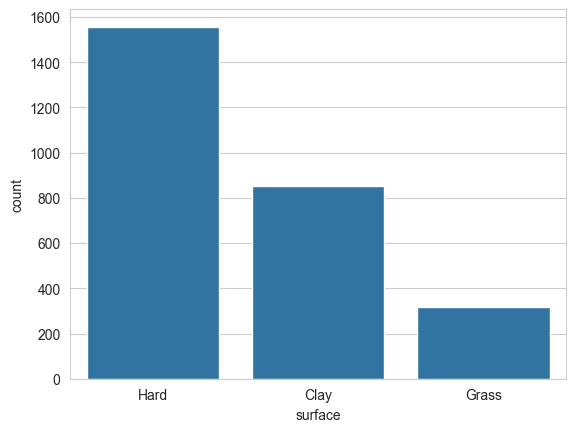

In [47]:
sns.countplot(x="surface", data=df)
plt.show()


In [48]:
df["tourney_name"].nunique()


67

In [49]:
df["tourney_name"].value_counts().head(10)


tourney_name
Wimbledon               127
Roland Garros           126
Us Open                 126
Australian Open         124
Indian Wells Masters     95
Madrid Masters           95
Rome Masters             95
Shanghai Masters         95
Miami Masters            93
Monte Carlo Masters      54
Name: count, dtype: int64

In [50]:
df["tourney_name"].nunique()


67

In [51]:
df["tourney_name"].value_counts().head(5)


tourney_name
Wimbledon               127
Roland Garros           126
Us Open                 126
Australian Open         124
Indian Wells Masters     95
Name: count, dtype: int64

In [52]:
df.groupby("tourney_name")["draw_size"].mean().sort_values(ascending=False).head()


tourney_name
Madrid Masters          128.0
Australian Open         128.0
Miami Masters           128.0
Indian Wells Masters    128.0
Roland Garros           128.0
Name: draw_size, dtype: float64

In [53]:
df["surface"].value_counts()


surface
Hard     1557
Clay      852
Grass     318
Name: count, dtype: int64

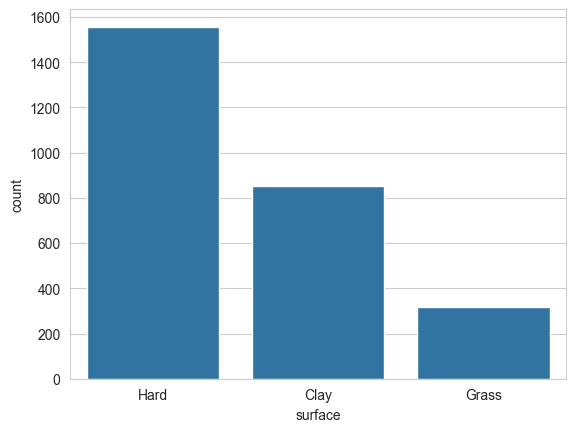

In [54]:
sns.countplot(x="surface", data=df)
plt.show()


In [55]:
df["surface"].value_counts()


surface
Hard     1557
Clay      852
Grass     318
Name: count, dtype: int64

In [56]:
df["surface"].value_counts(normalize=True) * 100


surface
Hard     57.095710
Clay     31.243124
Grass    11.661166
Name: proportion, dtype: float64

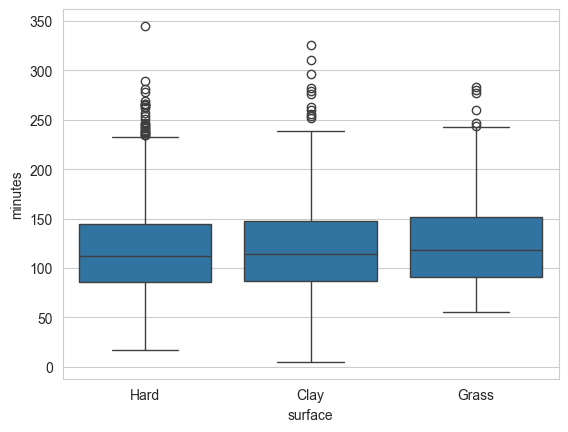

In [57]:
sns.boxplot(x="surface", y="minutes", data=df)
plt.show()


In [58]:
df.groupby("surface")["minutes"].mean()


surface
Clay     120.260563
Grass    126.364780
Hard     118.446371
Name: minutes, dtype: float64

In [59]:

df[df["best_of"] == 3].groupby("surface")["minutes"].mean()


surface
Clay     110.825069
Grass    104.256545
Hard     109.465944
Name: minutes, dtype: float64

Grass matches had the highest average duration (~126 minutes), likely influenced by Wimbledon best-of-5 matches. Clay matches were slightly longer than hard-court matches, consistent with slower rally-heavy play on clay.

In [60]:
(df["rank_diff"] > 0).mean() * 100


np.float64(63.25632563256326)

Higher-ranked players won approximately 63% of matches in 2023, indicating that rankings are moderately predictive but upsets occur in roughly 37% of matches

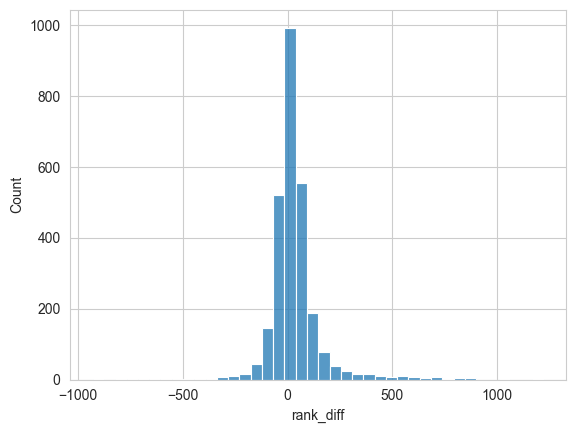

In [61]:
sns.histplot(df["rank_diff"], bins=40)
plt.show()


In [62]:
df["rank_diff"].describe()


count    2727.000000
mean       31.387239
std       134.430795
min      -930.000000
25%       -21.000000
50%        18.000000
75%        60.500000
max      1222.000000
Name: rank_diff, dtype: float64

In [63]:
df[df["rank_diff"] > 500][["winner_name", "loser_name", "winner_rank", "loser_rank"]]


,winner_name,loser_name,winner_rank,loser_rank
5,Lorenzo Musetti,Stefanos Sakellaridis,23.0,803.0
7,Borna Gojo,Stefanos Sakellaridis,144.0,803.0
71,Jannik Sinner,Kyle Edmund,15.0,582.0
124,Richard Gasquet,Kiranpal Pannu,67.0,575.0
150,Miomir Kecmanovic,Kyle Edmund,28.0,583.0
183,Jannik Sinner,Kyle Edmund,16.0,581.0
295,Hugo Dellien,Guido Pella,138.0,1018.0
379,Marcos Giron,Matija Pecotic,55.0,784.0
414,Jaume Munar,Guido Pella,67.0,723.0
495,Carlos Alcaraz,Mateus Alves,2.0,556.0


The average ranking difference between winner and loser was approximately 31 positions. However, the median difference was 18, indicating that most matches were between relatively close-ranked players. Extreme mismatches exist but are rare. Rankings are predictive but not deterministic.

In [64]:
df["winner_age"].describe()


count    2727.000000
mean       26.627246
std         4.293113
min        17.900000
25%        24.000000
50%        26.200000
75%        28.700000
max        41.700000
Name: winner_age, dtype: float64

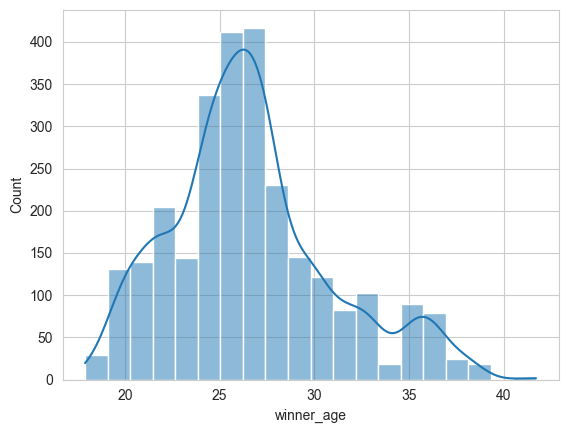

In [65]:
sns.histplot(df["winner_age"], bins=20, kde=True)
plt.show()


In [ ]:
## Key Insights

- Higher-ranked players won approximately 63% of matches, showing that rankings are predictive but upsets remain common.
- Hard courts dominated the 2023 ATP season, accounting for over 57% of all matches.
- Grass matches had the highest average duration, likely influenced by Grand Slam (best-of-5) formats.
- Most matches occurred between relatively close-ranked players, indicating competitive balance across tournaments.

In [ ]:
## Conclusion

The 2023 ATP season analysis highlights the structure of the professional tennis calendar, the dominance of hard-court tournaments, and the moderate predictive strength of ATP rankings. While higher-ranked players tend to win more often, a significant proportion of matches result in upsets, reflecting competitive depth within the tour.